In [222]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [185]:
Data = pd.read_csv('../Data/Nova_pay_combined.csv')

In [186]:
pd.set_option('display.max_columns',None)
Data.head(5)


,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [187]:
Data['is_fraud'].value_counts()

is_fraud
0    10403
1      997
Name: count, dtype: int64

#This data has problem of class imbalance - SMOTE TECHNIQUES

In [188]:

Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  str    
 1   customer_id                11400 non-null  str    
 2   timestamp                  11371 non-null  str    
 3   home_country               11400 non-null  str    
 4   source_currency            11400 non-null  str    
 5   dest_currency              11400 non-null  str    
 6   channel                    11400 non-null  str    
 7   amount_src                 11400 non-null  str    
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  str    
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  str    
 14  i

In [189]:
# checkng for null values
Data.isnull().mean()*100>0
null_columns = Data.isnull().mean()*100>0
null_columns[null_columns ==True].index.tolist()

['timestamp',
 'amount_usd',
 'fee',
 'ip_address',
 'ip_country',
 'kyc_tier',
 'device_trust_score']

In [190]:
Data.describe(include = ['str','bool'])

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,device_id,new_device,ip_address,ip_country,location_mismatch,kyc_tier
count,11400,11400,11371,11400,11400,11400,11400,11400,11400,11400,11095,11099,11400,11100
unique,11200,1315,11141,7,3,9,12,9856,2113,2,10900,9,2,14
top,4662cb2d-21b2-4390-ba38-5a1eddebdc7c,402cccc9-28de-45b3-9af7-cc5302aa1f93,0000-00-00T00:00:00Z,US,USD,NGN,mobile,100.0,e70db499-19e1-4927-b04f-3ebfcf62e33c,False,194.179.17.152,US,False,standard
freq,2,1510,21,7940,8031,1474,6366,15,87,10047,2,6848,9548,7931


In [191]:
Data.describe()

,amount_usd,fee,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,11095.000000,11105.000000,11400.000000,11400.000000,11400.000000,11105.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000
mean,452.022083,100.309441,167.540397,0.396726,393.793158,0.653681,0.048509,0.267134,0.458333,0.723509,0.045501,0.087456
std,1403.973062,958.128504,382.023827,0.270507,342.348393,0.273012,0.256194,0.142983,1.524494,1.958390,0.084942,0.282515
min,7.230000,-1.000000,0.592000,0.004000,1.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,92.465000,2.380000,1.000000,0.209000,147.000000,0.515000,0.000000,0.169000,0.000000,0.000000,0.000000,0.000000
50%,163.480000,3.500000,7.142857,0.325000,298.000000,0.658000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,302.190000,5.550000,73.529412,0.487000,661.000000,0.894000,0.000000,0.391000,0.000000,0.000000,0.050000,0.000000
max,12498.570000,9999.990000,1388.888889,1.200000,1095.000000,0.999000,2.000000,0.900000,8.000000,11.000000,0.250000,1.000000


In [192]:
Data.duplicated().sum()

np.int64(200)

In [193]:
# conversion to the right data types.
Data['timestamp'] = pd.to_datetime(Data['timestamp'], errors='coerce')
Data['amount_src'] = pd.to_numeric(Data['amount_src'], errors ='coerce')
                                

In [194]:
Data[['amount_src','timestamp']].dtypes

amount_src                float64
timestamp     datetime64[us, UTC]
dtype: object

In [195]:
 for col in Data.select_dtypes(include=['str','bool']).columns.tolist():
        print(Data[col].value_counts())
        print('------------------------------------')

transaction_id
4662cb2d-21b2-4390-ba38-5a1eddebdc7c    2
e69d481f-2ee3-4621-a58a-73fec8c63eca    2
8537371a-7eae-4108-89c9-5660e5025a88    2
2e553c23-063e-4b5e-aa2e-8a41d6aa61ca    2
a9198fb0-d831-48df-b434-c30a39078aa3    2
                                       ..
b5ef3323-46d2-4f6c-9c19-43df4e55df48    1
54f00f78-94aa-4a08-bf6b-12877aa47186    1
6a51f0e8-f5d1-4fe6-91a0-655fccd79fa5    1
4aad7389-2b62-4885-a23e-aa3ecd5cfaf9    1
fdffeb16-192a-4483-9b1e-9928e23269c2    1
Name: count, Length: 11200, dtype: int64
------------------------------------
customer_id
402cccc9-28de-45b3-9af7-cc5302aa1f93    1510
d71c91b4-fee8-4104-9856-a5c6109a62e3    1355
7041b9c1-3719-4ca8-9a6b-811b47cea6c0    1345
6d0d9b27-fa26-45f8-93b1-2df29d182d9c    1066
af8ca4c4-8703-4c55-b66c-2b76cd70040d     915
                                        ... 
8734e6a7-f34e-49f2-b559-1d62a756664c       1
c18070a6-bdb9-4df3-9df7-5d92c0bff424       1
2003e2a1-f3b1-4e2e-8d0e-488cfacf68ca       1
8b1cf558-4ed7-48ee-b330-75db

## Task DuE Monday
. Dropping identifiers
. deal with duplicates
. Deal with null values
. fix home country to be consistent


DROPPING IDENTIFIERS COLUMN

In [233]:
Data = Data.drop(columns=['transaction_id','customer_id','device_id'])
Data.head(5)

KeyError: "['transaction_id', 'customer_id', 'device_id'] not found in axis"

   DROPPING DUPLICATES

In [ ]:
# checking the data duplicates
Data.duplicated().sum()

np.int64(200)

In [ ]:
Data = Data.drop_duplicates()

In [ ]:
Data.duplicated().sum()

np.int64(0)

Dealing With Inconsistent Categorical Variables

In [ ]:
# Removing leading and trailing spaces and converting to lower case in string columns
for col in Data.select_dtypes(include=['str']).columns.tolist():
    Data[col] = Data[col].str.strip().str.lower()
   

In [ ]:
# correcting typos in categorical columns
typo_corrections ={
   'channel':{'mobille':'mobile','weeb':'web'}, 
   'ip_country':{'nan': 'unknown'},
   'kyc_tier':{'standrd':'standard','enhancd':'enhanced','nan':'unknown'},
   }
for col, corrections in typo_corrections.items():
    Data[col] = Data[col].replace(corrections)

In [ ]:
# checking the value counts of categorical columns after cleaning
for col in Data.select_dtypes(include=['str','bool']).columns.tolist():
        print(Data[col].value_counts())
        print('------------------------------------')

home_country
us         7852
uk         2104
ca         1212
unknown      32
Name: count, dtype: int64
------------------------------------
source_currency
usd    7875
gbp    2111
cad    1214
Name: count, dtype: int64
------------------------------------
dest_currency
ngn    1447
inr    1304
usd    1302
cny    1297
php    1290
gbp    1273
cad    1260
eur    1177
mxn     850
Name: count, dtype: int64
------------------------------------
channel
mobile     6395
web        3766
atm        1002
unknown      37
Name: count, dtype: int64
------------------------------------
new_device
False    9864
True     1336
Name: count, dtype: int64
------------------------------------
ip_address
221.78.171.180     1
120.12.20.29       1
223.96.181.93      1
186.228.15.74      1
11.82.47.62        1
                  ..
221.126.239.197    1
26.6.123.44        1
184.150.56.237     1
31.125.175.93      1
216.205.157.160    1
Name: count, Length: 10900, dtype: int64
------------------------------------
ip_

Dealing With Null Values

In [ ]:
null_values = Data.isnull().sum () 
null_columns = null_values[null_values> 0]
print(null_columns)


timestamp              60
amount_src              4
amount_usd            300
fee                   290
ip_address            300
ip_country            296
kyc_tier              295
device_trust_score    290
dtype: int64


In [ ]:
null_columns.dtype

dtype('int64')

In [ ]:
# filling the null values in numeric columns with mean value
Data.fillna(Data.mean(numeric_only=True), inplace=True)

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.00,0
1,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.00,0
2,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.00,0
3,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.00,0
4,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11395,2025-11-25 10:05:35.573611+00:00,US,USD,CAD,mobile,271.25,271.25,5.24,1.351351,False,221.126.239.197,US,False,0.307,standard,742,0.653,0,0.302,1,2,0.00,0
11396,2025-11-26 07:09:56.573611+00:00,CA,CAD,NGN,web,537.17,397.51,8.86,822.222222,False,26.6.123.44,UK,True,0.891,low,9,0.173,2,0.730,3,6,0.00,1
11397,2025-11-27 06:19:11.573611+00:00,CA,CAD,INR,web,205.15,151.81,4.00,61.666667,True,184.150.56.237,US,True,1.000,low,21,0.269,1,0.605,3,4,0.12,1
11398,2025-11-28 00:53:28.573611+00:00,US,USD,PHP,mobile,78.03,78.03,1.96,58.823529,False,31.125.175.93,US,False,0.298,enhanced,471,0.773,0,0.375,0,2,0.00,0


In [ ]:
# filling the null values in categorical columns with mode value
for col in Data.select_dtypes(include=['object', 'string']).columns:
    Data[col] = Data[col].fillna(Data[col].mode()[0])

# EDA

1) FRAUD VS AMOUNT

<Axes: xlabel='is_fraud', ylabel='amount_usd'>

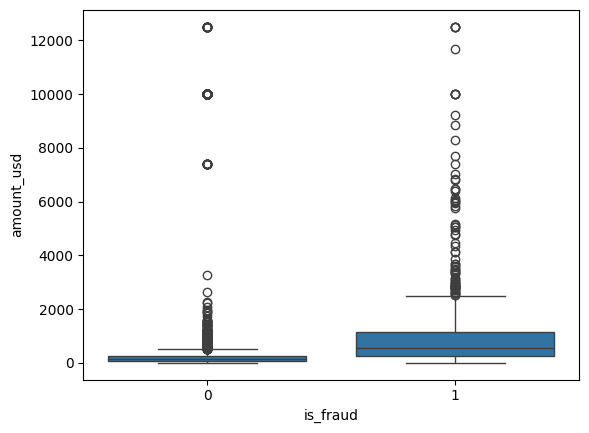

In [ ]:
sns.boxplot(
    x='is_fraud',
    y='amount_usd',
    data=Data
)

Business insights:
             Fraudulent transactions tend to involve larger transaction amounts than legitimate transactions. The median transaction amount for fraudulent transactions is substantially higher, and fraud cases exhibit greater variability and more extreme high-value transactions. This suggests that transaction amount is a potentially important predictor of fraudulent behaviour. 

2) CURRENCY ANALYSIS

In [ ]:
fraud_rate = Data.groupby('source_currency')['is_fraud'].mean()

<Axes: xlabel='source_currency'>

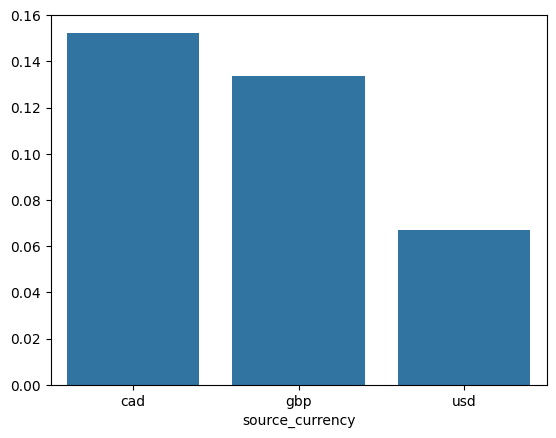

In [ ]:
sns.barplot(
    x=fraud_rate.index,
    y=fraud_rate.values
)

Business insight:

Fraud rates vary across source currencies. Transactions originating in CAD exhibited the highest fraud rate (approximately 15%), followed by GBP (13%), while USD transactions showed the lowest fraud rate (around 6%). This suggests that source currency may provide useful predictive information for fraud detection models.

3) Channel Analysis

In [234]:
pd.crosstab(
    Data['channel'],
    Data['is_fraud'],
    normalize='index'
)

is_fraud,0,1
channel,,
atm,0.919162,0.080838
mobile,0.953245,0.046755
unknown,0.972973,0.027027
web,0.836962,0.163038


Business Insight:

Channel analysis revealed substantial differences in fraud rates. Web transactions had the highest fraud incidence (16.3%), followed by ATM transactions (8.1%). Mobile transactions exhibited a considerably lower fraud rate (4.7%), while transactions with unknown channels showed the lowest fraud rate (2.7%). These findings suggest that transaction channel is an important predictor of fraud risk and should be incorporated into fraud detection models.

4) Account Age Analysis

<Axes: xlabel='is_fraud', ylabel='account_age_days'>

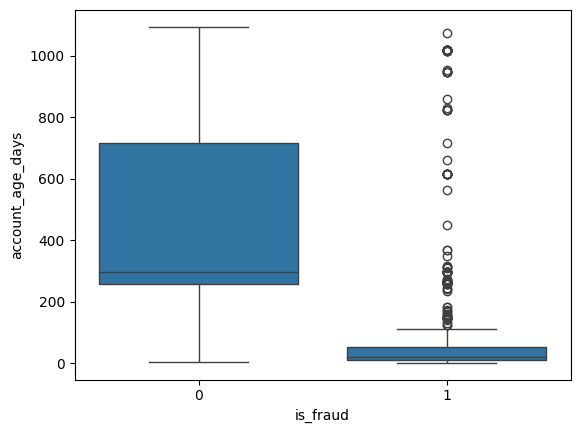

In [235]:
sns.boxplot(
    x='is_fraud',
    y='account_age_days',
    data=Data
)

Business Insights:

Account age demonstrated a strong relationship with fraudulent behaviour. Fraudulent transactions were predominantly associated with younger accounts, with a substantially lower median account age compared to legitimate transactions. This suggests that newly created accounts represent a higher fraud risk and account age should be considered an important predictive feature.

5) Velocity Analysis

<Axes: xlabel='is_fraud', ylabel='txn_velocity_1h'>

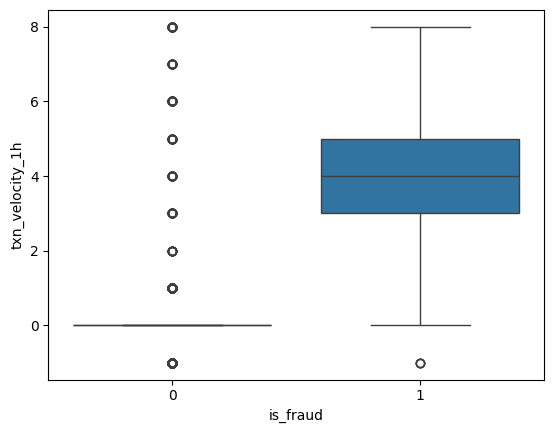

In [ ]:
# checking the distribution of transaction velocity in the last 1 hour for fraudulent and non-fraudulent transactions
sns.boxplot(
    x='is_fraud',
    y='txn_velocity_1h',
    data=Data
)

Business Insight:
Fraudsters tend to perform multiple transactions in a short period of time, while genuine customers typically transact much less frequently.

<Axes: xlabel='is_fraud', ylabel='txn_velocity_24h'>

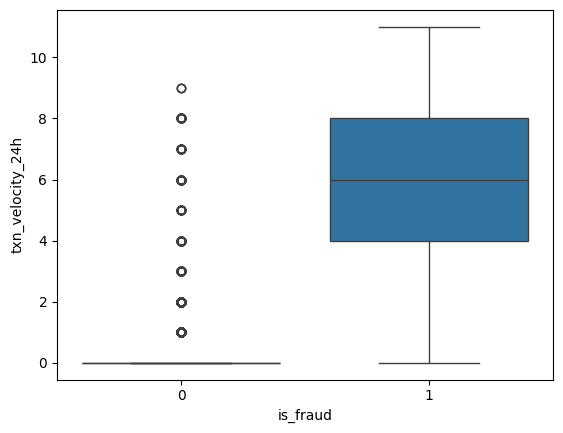

In [ ]:
# checking the distribution of transaction velocity in the last 1 hour for fraudulent and non-fraudulent transactions
sns.boxplot(
    x='is_fraud',
    y='txn_velocity_24h',
    data=Data
)

Business Insight:

Fraudulent accounts exhibit significantly higher transaction activity over a 24-hour period than legitimate accounts

6) Device Trust score

<Axes: xlabel='is_fraud', ylabel='device_trust_score'>

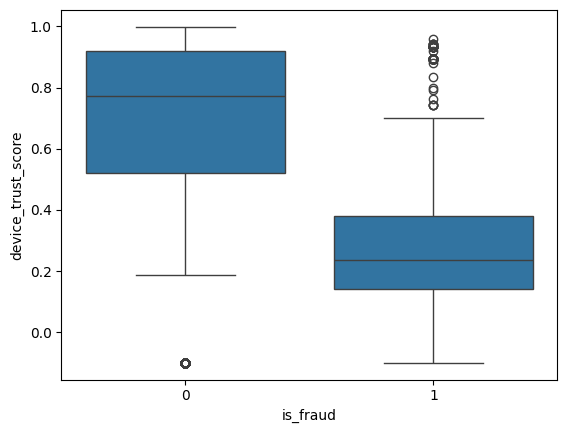

In [239]:
sns.boxplot(
    x='is_fraud',
    y='device_trust_score',
    data=Data
)

Business Insight:

Device trust score exhibited a strong inverse relationship with fraudulent activity. Fraudulent transactions were predominantly associated with lower trust scores, while legitimate transactions generally originated from highly trusted devices. This indicates that device trust score is a valuable predictor for identifying potentially fraudulent transactions